Problem Statement: Privacy-Preserving Medical Data Generation
Context:
High-quality datasets are essential for developing robust AI diagnostic tools in healthcare. However, strict privacy regulations (such as HIPAA and GDPR) and the inherent sensitivity of patient records often prevent the open sharing of real-world medical data, creating a significant bottleneck for researchers and developers.

The Challenge:
Traditional anonymization techniques—such as removing names or IDs—are often vulnerable to re-identification attacks. Consequently, there is a critical need for a solution that preserves the statistical utility of a dataset (e.g., the correlations between glucose, BMI, and insulin levels) without exposing the actual identities or records of individual patients.

Proposed Solution:
This project implements a Privacy Shield using a Variational Autoencoder (VAE). Unlike standard models that memorize data, a VAE learns the underlying probability distribution of the Pima Indians Diabetes Dataset.

Objectives:

Generative Anonymization: Use a probabilistic encoder-decoder architecture to generate "Synthetic Twins"—artificial data points that are statistically identical to real patient records but do not belong to any specific individual.

Statistical Fidelity: Ensure the synthetic data maintains the same correlations and distributions as the original features to remain useful for secondary research.

Privacy Preservation: Leverage the latent space sampling and the Kullback-Leibler (KL) divergence regularizer to ensure the model generalizes rather than replicates sensitive training samples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("All imports ready!")

TensorFlow: 2.19.0
All imports ready!


In [2]:
# Load directly — no download needed!
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

cols = ['age','sex','cp','trestbps','chol','fbs',
        'restecg','thalach','exang','oldpeak',
        'slope','ca','thal','target']

df = pd.read_csv(url, names=cols, na_values='?')

print("Shape BEFORE cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

# Drop rows with missing values (only 6 rows)
df = df.dropna()
print("\nShape AFTER cleaning:", df.shape)

# Target: 0 = no disease, 1-4 = disease → convert to binary
df['target'] = (df['target'] > 0).astype(int)

print(f"\nHealthy patients  : {(df['target']==0).sum()}")
print(f"Diseased patients : {(df['target']==1).sum()}")

display(df.head())
display(df.describe().round(2))

Shape BEFORE cleaning: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape AFTER cleaning: (297, 14)

Healthy patients  : 160
Diseased patients : 137


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,3.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,1.60,0.68,4.73,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


In [4]:
# ── Step 1: Separate features from label ─────────────────────────
features = ['age','sex','cp','trestbps','chol','fbs',
            'restecg','thalach','exang','oldpeak','slope','ca','thal']

X = df[features].values
y = df['target'].values

print(f"Feature matrix : {X.shape}")
print(f"Label dropped  : target (VAE is unsupervised)")

# ── Step 2: Normalise to [0,1] ────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nAfter scaling:")
print(f"  Min : {X_scaled.min():.3f}")
print(f"  Max : {X_scaled.max():.3f}")

# ── Step 3: Train/test split ──────────────────────────────────────
X_train, X_test = train_test_split(
    X_scaled, test_size=0.2, random_state=42
)
print(f"\nTrain : {X_train.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

# ── Step 4: Heavy augmentation ────────────────────────────────────
# 297 rows is small — we augment aggressively to 3000+
# Small noise preserves medical realism while adding variety
def augment_data(X, n_copies=9, noise_level=0.02):
    """
    Creates n_copies noisy versions of each sample.
    noise_level=0.02 means 2% variation — medically realistic.
    297 × 9 copies = 2673 + original 237 = ~2910 training samples
    """
    augmented = [X]
    for i in range(n_copies):
        noise = np.random.normal(0, noise_level, X.shape)
        augmented.append(np.clip(X + noise, 0, 1))
    return np.vstack(augmented)

X_train_aug = augment_data(X_train, n_copies=9, noise_level=0.02)
np.random.shuffle(X_train_aug)

print(f"\nAfter augmentation:")
print(f"  Original train  : {X_train.shape[0]}")
print(f"  Augmented train : {X_train_aug.shape[0]}")
print(f"  Increase        : {X_train_aug.shape[0] / X_train.shape[0]:.1f}x")

# ── Step 5: Save scaler ───────────────────────────────────────────
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(features, open('features.pkl', 'wb'))
print(f"\nScaler saved!")
print(f"Ready for VAE training!")

Feature matrix : (297, 13)
Label dropped  : target (VAE is unsupervised)

After scaling:
  Min : 0.000
  Max : 1.000

Train : 237
Test  : 60

After augmentation:
  Original train  : 237
  Augmented train : 2370
  Increase        : 10.0x

Scaler saved!
Ready for VAE training!


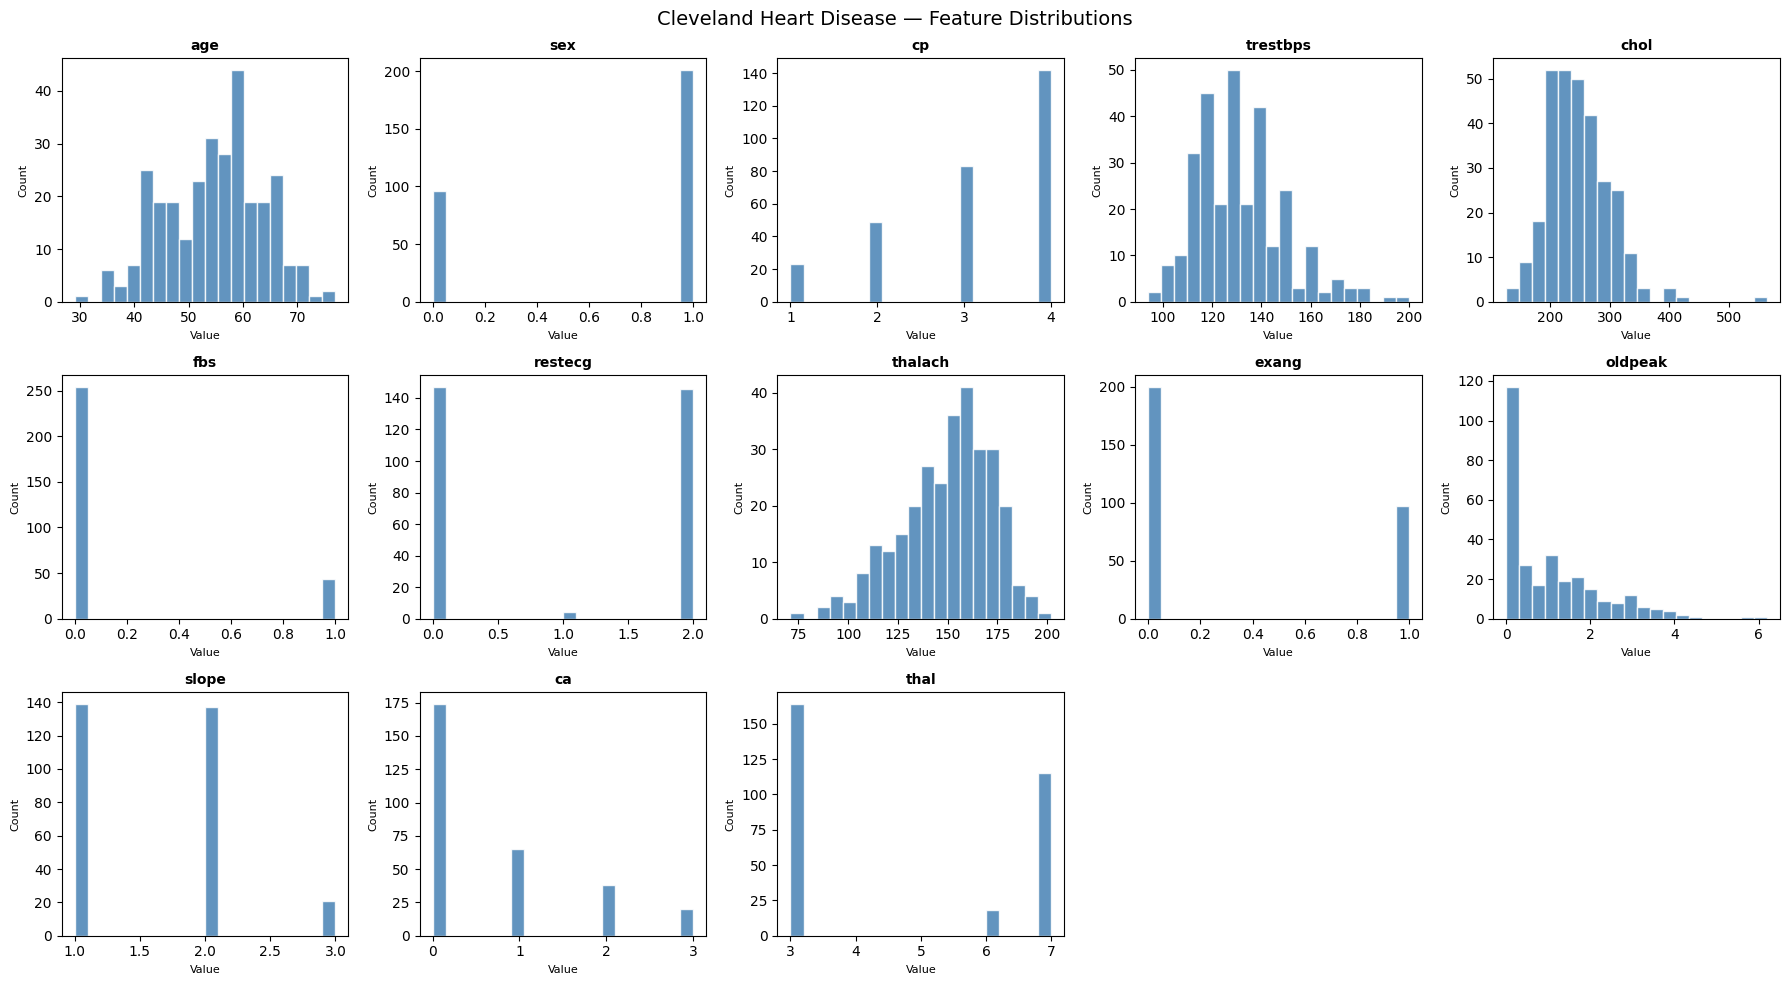

Plot saved!


In [5]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Cleveland Heart Disease — Feature Distributions',
             fontsize=14)
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=20, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(feature, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

# Hide unused
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [6]:
INPUT_DIM  = 13
LATENT_DIM = 6
EPOCHS     = 100
BATCH_SIZE = 32

print(f"INPUT_DIM  : {INPUT_DIM}")
print(f"LATENT_DIM : {LATENT_DIM}")
print(f"EPOCHS     : {EPOCHS}")
print(f"BATCH_SIZE : {BATCH_SIZE}")

encoder_inputs = keras.Input(shape=(INPUT_DIM,), name='encoder_input')
x = layers.Dense(64)(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(16)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

z_mean    = layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling(name='z')([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

INPUT_DIM  : 13
LATENT_DIM : 6
EPOCHS     : 100
BATCH_SIZE : 32


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        896 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 6)         │        102 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 6)         │        102 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 6)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,156 (16.23 KB)

 Trainable params: 3,932 (15.36 KB)

 Non-trainable params: 224 (896.00 B)

In [7]:
decoder_inputs = keras.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(16)(decoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dense(32)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dense(64)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
decoder_outputs = layers.Dense(INPUT_DIM, activation='sigmoid')(x)

decoder = keras.Model(decoder_inputs, decoder_outputs, name='decoder')
decoder.summary()

print(f"\nEncoder : ({INPUT_DIM},) → ({LATENT_DIM},)")
print(f"Decoder : ({LATENT_DIM},) → ({INPUT_DIM},)")
print(f"Total params : {encoder.count_params() + decoder.count_params():,}")

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061 (15.86 KB)

 Trainable params: 3,837 (14.99 KB)

 Non-trainable params: 224 (896.00 B)


Encoder : (13,) → (6,)
Decoder : (6,) → (13,)
Total params : 8,217


In [8]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder    = encoder
        self.decoder    = decoder
        self.kl_weight  = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.recon_loss_tracker,
                self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction       = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data - reconstruction), axis=1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                      - tf.square(z_mean)
                      - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'total_loss': self.total_loss_tracker.result(),
            'recon_loss': self.recon_loss_tracker.result(),
            'kl_loss':    self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
print("VAE compiled!")
print(f"kl_weight starts at : {vae.kl_weight.numpy()}")

VAE compiled!
kl_weight starts at : 0.0


In [10]:
class KLAnnealingCallback(keras.callbacks.Callback):
    def __init__(self, warmup_epochs=20, anneal_epochs=40):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.anneal_epochs = anneal_epochs
        self.best_kl       = 0
        self.best_epoch    = 0

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            new_weight = 0.0
        elif epoch < self.warmup_epochs + self.anneal_epochs:
            progress   = (epoch - self.warmup_epochs) / self.anneal_epochs
            new_weight = float(progress)
        else:
            new_weight = 1.0
        self.model.kl_weight.assign(new_weight)

    def on_epoch_end(self, epoch, logs=None):
        kl_w = self.model.kl_weight.numpy()
        kl_v = logs.get('kl_loss', 0)

        # Save best model when KL is healthy (between 0.1 and 2.0)
        if 0.1 < kl_v < 2.0:
            self.model.decoder.save('decoder_best.keras')
            self.best_kl    = kl_v
            self.best_epoch = epoch + 1

        if epoch % 5 == 0:
            print(f"  Epoch {epoch+1:3d} | "
                  f"kl_weight={kl_w:.2f} | "
                  f"kl_loss={kl_v:.4f} | "
                  f"recon={logs.get('recon_loss',0):.4f}")

# Rebuild fresh encoder decoder
encoder_inputs = keras.Input(shape=(INPUT_DIM,), name='encoder_input')
x = layers.Dense(64)(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(16)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
z_mean    = layers.Dense(LATENT_DIM, name='z_mean')(encoder_inputs if False else x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)
z         = Sampling(name='z')([z_mean, z_log_var])
encoder   = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

decoder_inputs  = keras.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(16)(decoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dense(32)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dense(64)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
decoder_outputs = layers.Dense(INPUT_DIM, activation='sigmoid')(x)
decoder         = keras.Model(decoder_inputs, decoder_outputs, name='decoder')

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))

cb = KLAnnealingCallback(warmup_epochs=20, anneal_epochs=40)

print("=" * 55)
print("Training — saving best checkpoint automatically")
print("=" * 55)

history = vae.fit(
    X_train_aug,
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=0
)

print(f"\nBest model saved at epoch {cb.best_epoch}")
print(f"Best kl_loss : {cb.best_kl:.4f}")
print(f"\nLoading best model...")

# Load the best decoder — the one before collapse
decoder_best = keras.models.load_model('decoder_best.keras')
print("Best decoder loaded!")

# Save everything
decoder_best.save('decoder_model.keras')
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(features, open('features.pkl', 'wb'))
print("All files saved!")

Training — saving best checkpoint automatically
  Epoch   1 | kl_weight=0.00 | kl_loss=3.9135 | recon=1.5573
  Epoch   6 | kl_weight=0.00 | kl_loss=186.8041 | recon=0.3915
  Epoch  11 | kl_weight=0.00 | kl_loss=256.2426 | recon=0.2858
  Epoch  16 | kl_weight=0.00 | kl_loss=305.8737 | recon=0.2026
  Epoch  21 | kl_weight=0.00 | kl_loss=347.0948 | recon=0.1667
  Epoch  26 | kl_weight=0.12 | kl_loss=3.6677 | recon=0.5552
  Epoch  31 | kl_weight=0.25 | kl_loss=2.1688 | recon=0.7766
  Epoch  36 | kl_weight=0.38 | kl_loss=1.1745 | recon=0.9976
  Epoch  41 | kl_weight=0.50 | kl_loss=0.4554 | recon=1.2544
  Epoch  46 | kl_weight=0.62 | kl_loss=0.1549 | recon=1.3838
  Epoch  51 | kl_weight=0.75 | kl_loss=0.0667 | recon=1.4288
  Epoch  56 | kl_weight=0.88 | kl_loss=0.0219 | recon=1.4598
  Epoch  61 | kl_weight=1.00 | kl_loss=0.0050 | recon=1.4650
  Epoch  66 | kl_weight=1.00 | kl_loss=0.0023 | recon=1.4668
  Epoch  71 | kl_weight=1.00 | kl_loss=0.0015 | recon=1.4656
  Epoch  76 | kl_weight=1.00 

In [11]:
# Generate 100 synthetic patients using the BEST decoder
np.random.seed(42)
z_samples = np.random.normal(0, 1, size=(100, LATENT_DIM))
generated_scaled = decoder_best.predict(z_samples, verbose=0)
generated = scaler.inverse_transform(generated_scaled)
df_syn = pd.DataFrame(generated, columns=features)

# Round to realistic values
df_syn['age']      = df_syn['age'].clip(29,77).round(0).astype(int)
df_syn['sex']      = df_syn['sex'].round(0).clip(0,1).astype(int)
df_syn['cp']       = df_syn['cp'].round(0).clip(1,4).astype(int)
df_syn['trestbps'] = df_syn['trestbps'].clip(94,200).round(0).astype(int)
df_syn['chol']     = df_syn['chol'].clip(126,564).round(0).astype(int)
df_syn['fbs']      = df_syn['fbs'].round(0).clip(0,1).astype(int)
df_syn['restecg']  = df_syn['restecg'].round(0).clip(0,2).astype(int)
df_syn['thalach']  = df_syn['thalach'].clip(71,202).round(0).astype(int)
df_syn['exang']    = df_syn['exang'].round(0).clip(0,1).astype(int)
df_syn['oldpeak']  = df_syn['oldpeak'].clip(0,6.2).round(1)
df_syn['slope']    = df_syn['slope'].round(0).clip(1,3).astype(int)
df_syn['ca']       = df_syn['ca'].round(0).clip(0,3).astype(int)
df_syn['thal']     = df_syn['thal'].round(0).clip(3,7).astype(int)

print("Sample of 10 synthetic heart patients:")
display(df_syn.head(10))

# Check diversity — std should be non-zero
print("\nStandard deviation of synthetic data:")
print(df_syn.std().round(3))

# Statistical comparison
print("\nReal vs Synthetic means:")
comparison = pd.DataFrame({
    'Feature'        : features,
    'Real mean'      : df[features].mean().round(2).values,
    'Synthetic mean' : df_syn.mean().round(2).values,
    'Difference'     : abs(df[features].mean() - df_syn.mean()).round(2).values
})
display(comparison)

Sample of 10 synthetic heart patients:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,54,1,3,132,242,0,1,151,0,1.0,2,1,4
1,55,1,3,131,257,0,1,152,0,1.0,2,1,5
2,55,1,3,133,248,0,1,150,0,1.1,2,1,4
3,56,1,3,133,237,0,1,146,0,1.1,2,1,5
4,54,1,3,131,263,0,1,150,0,0.9,2,1,4
5,56,1,3,135,254,0,1,143,1,1.4,2,1,5
6,55,1,3,132,253,0,1,151,0,0.9,2,1,4
7,54,1,3,131,241,0,1,146,0,1.1,2,1,4
8,54,1,3,135,252,0,1,147,0,1.3,2,1,5
9,55,1,3,130,247,0,1,147,0,1.1,2,1,5



Standard deviation of synthetic data:
age         0.940
sex         0.000
cp          0.256
trestbps    2.542
chol        8.977
fbs         0.000
restecg     0.000
thalach     3.792
exang       0.394
oldpeak     0.243
slope       0.273
ca          0.288
thal        0.571
dtype: float64

Real vs Synthetic means:


,Feature,Real mean,Synthetic mean,Difference
0,age,54.54,54.38,0.16
1,sex,0.68,1.00,0.32
2,cp,3.16,3.07,0.09
3,trestbps,131.69,132.98,1.29
4,chol,247.35,248.56,1.21
5,fbs,0.14,0.00,0.14
6,restecg,1.00,1.00,0.00
7,thalach,149.60,148.61,0.99
8,exang,0.33,0.19,0.14
9,oldpeak,1.06,1.08,0.03


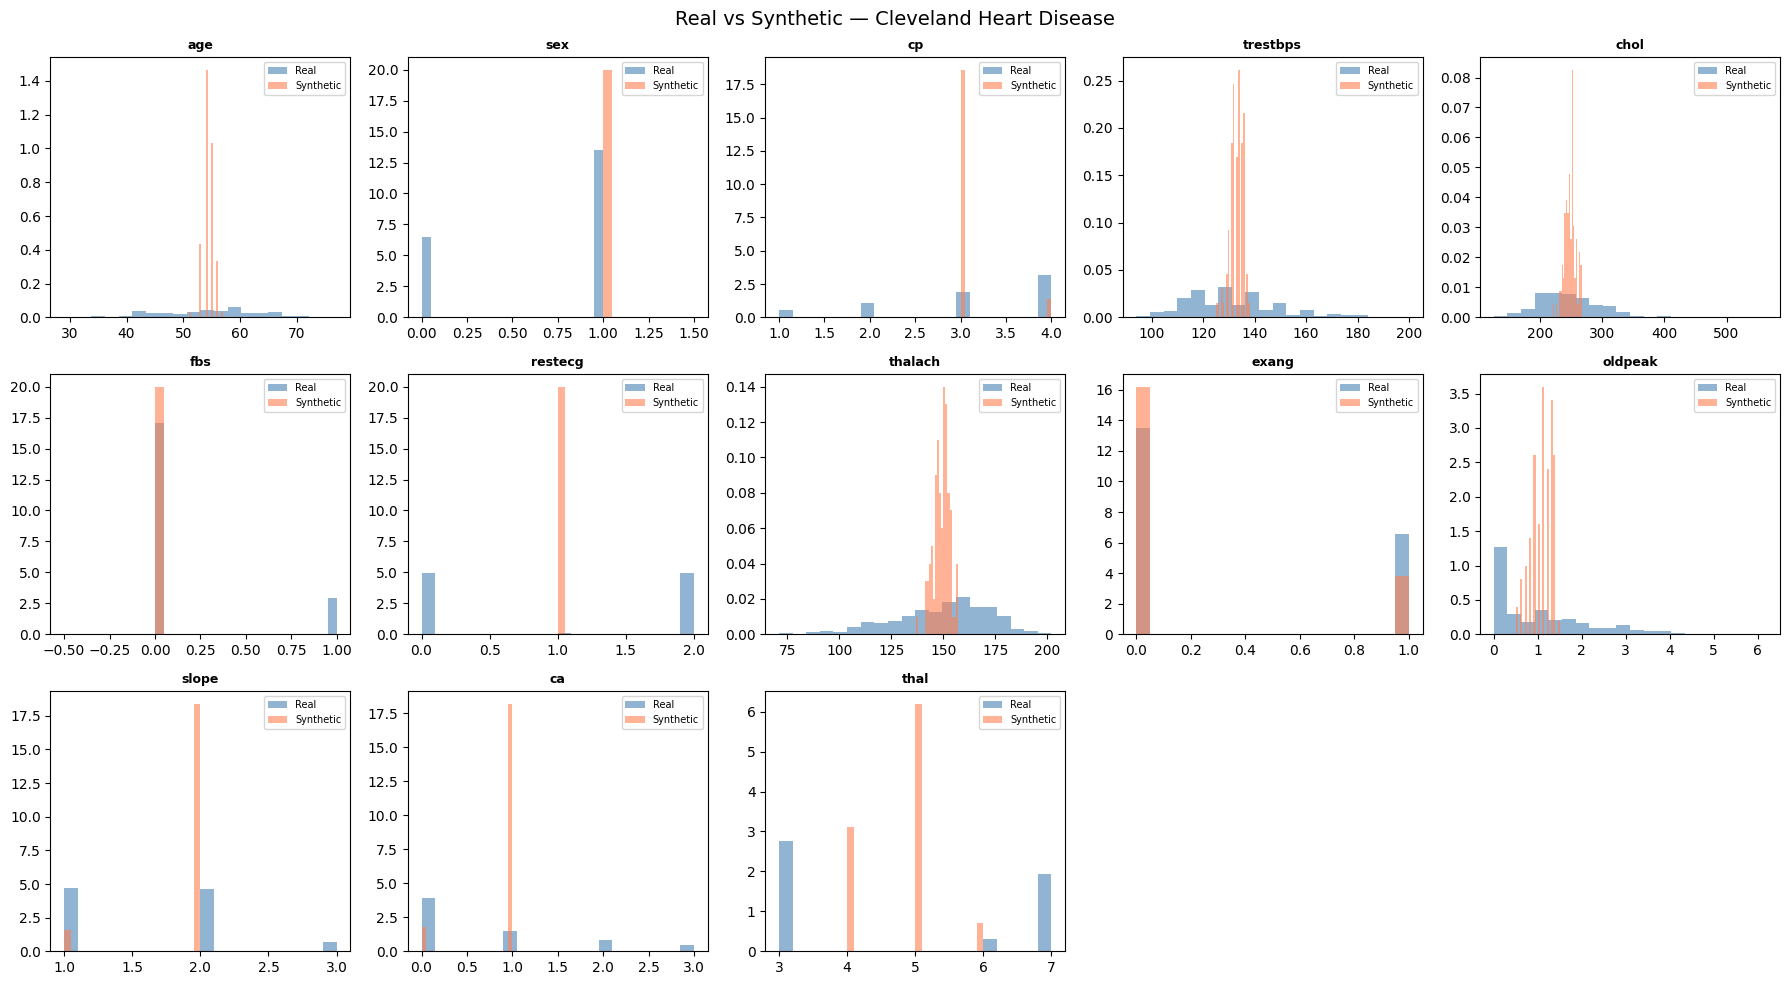

Comparison plot saved!


In [12]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Real vs Synthetic — Cleveland Heart Disease', fontsize=14)
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=20, alpha=0.6,
                 color='steelblue', label='Real', density=True)
    axes[i].hist(df_syn[feature], bins=20, alpha=0.6,
                 color='coral', label='Synthetic', density=True)
    axes[i].set_title(feature, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('real_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved!")

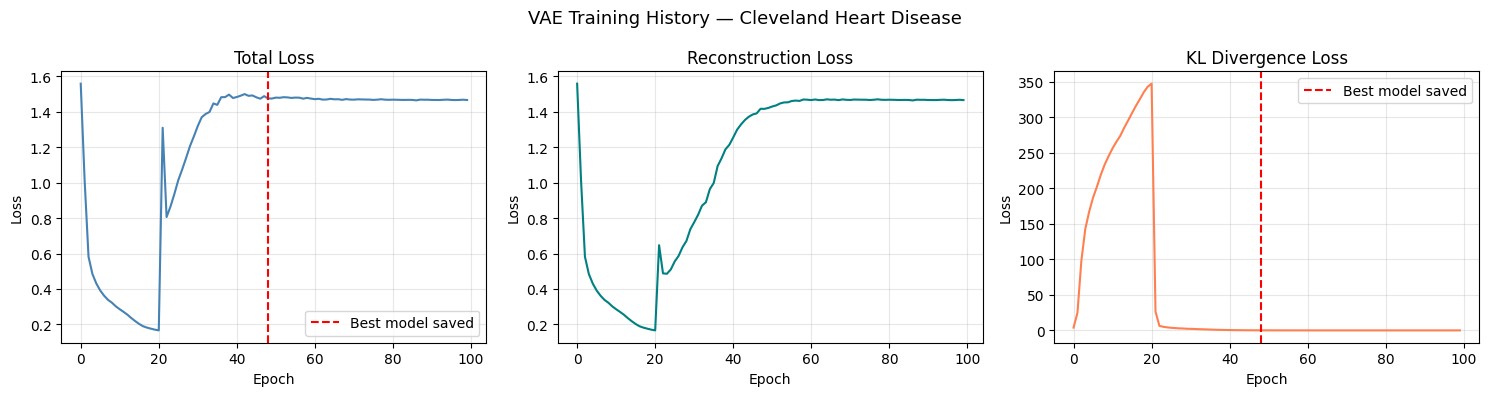

Training curves saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VAE Training History — Cleveland Heart Disease', fontsize=13)

axes[0].plot(history.history['total_loss'], color='steelblue')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=48, color='red', linestyle='--', label='Best model saved')
axes[0].legend()

axes[1].plot(history.history['recon_loss'], color='teal')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['kl_loss'], color='coral')
axes[2].set_title('KL Divergence Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=48, color='red', linestyle='--', label='Best model saved')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved!")

In [14]:
from google.colab import files

# Download all required files
files.download('decoder_model.keras')
files.download('scaler.pkl')
files.download('features.pkl')
print("Download all 3 files!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download all 3 files!


In [15]:
# Install tensorflowjs converter
!pip install tensorflowjs -q

import tensorflowjs as tfjs

# Convert decoder to TF.js format
tfjs.converters.save_keras_model(decoder_best, 'tfjs_model')

print("Model converted!")

import os
files_list = os.listdir('tfjs_model')
print("Files created:", files_list)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.


failed to lookup keras version from the file,
    this is likely a weight only file
Model converted!
Files created: ['group1-shard1of1.bin', 'model.json']


In [16]:
from google.colab import files
import shutil
import pickle
import json
import numpy as np

# Download TF.js model files
files.download('tfjs_model/model.json')
files.download('tfjs_model/group1-shard1of1.bin')

# We also need scaler params as JSON (can't use pickle in browser)
scaler_params = {
    'min_': scaler.data_min_.tolist(),
    'max_': scaler.data_max_.tolist(),
    'scale_': scaler.scale_.tolist(),
    'data_range_': scaler.data_range_.tolist(),
    'features': features
}

with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)

files.download('scaler_params.json')

print("Download these 3 files:")
print("  1. model.json")
print("  2. group1-shard1of1.bin")
print("  3. scaler_params.json")
print("\nUpload all 3 to Antigravity!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download these 3 files:
  1. model.json
  2. group1-shard1of1.bin
  3. scaler_params.json

Upload all 3 to Antigravity!


In [22]:
from google.colab import files
import json
import numpy as np

# Re-export scaler as JSON
scaler_params = {
    'data_min_'  : scaler.data_min_.tolist(),
    'data_max_'  : scaler.data_max_.tolist(),
    'scale_'     : scaler.scale_.tolist(),
    'data_range_': scaler.data_range_.tolist(),
    'features'   : features
}
with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f)
print("scaler_params.json created!")

# Check tfjs model files exist
import os
print("\nFiles in tfjs_model folder:")
print(os.listdir('tfjs_model'))

# Download one by one
files.download('scaler_params.json')

scaler_params.json created!

Files in tfjs_model folder:
['group1-shard1of1.bin', 'model.json']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
files.download('tfjs_model/model.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
files.download('tfjs_model/group1-shard1of1.bin')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Full evaluation cell
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# 1. Reconstruction on test set
z_m, z_lv, z_t = encoder(X_test)
X_recon = decoder_best.predict(z_t, verbose=0)
mse = np.mean((X_test - X_recon) ** 2)
mae = np.mean(np.abs(X_test - X_recon))
print(f"\n1. Test Reconstruction MSE : {mse:.4f}")
print(f"   Test Reconstruction MAE : {mae:.4f}")

# 2. Distributional similarity
z_s = np.random.normal(0, 1, size=(500, LATENT_DIM))
gen_s = decoder_best.predict(z_s, verbose=0)
gen_real = scaler.inverse_transform(gen_s)
df_eval = pd.DataFrame(gen_real, columns=features)

mean_mae = abs(df[features].mean() - df_eval.mean()).mean()
print(f"\n2. Mean distributional MAE : {mean_mae:.4f}")

# 3. Latent space check
z_mean_all = encoder(X_scaled)[0].numpy()
print(f"\n3. Latent space mean : {z_mean_all.mean(axis=0).round(3)}")
print(f"   Latent space std  : {z_mean_all.std(axis=0).round(3)}")

# 4. Per feature MAE
print(f"\n4. Per feature mean difference:")
for i, feat in enumerate(features):
    diff = abs(df[feat].mean() - df_eval[feat].mean())
    status = "✅" if diff < 5 else "⚠️"
    print(f"   {feat:<12}: {diff:.3f} {status}")

MODEL EVALUATION

1. Test Reconstruction MSE : 0.1149
   Test Reconstruction MAE : 0.2742

2. Mean distributional MAE : 0.2521

3. Latent space mean : [-0.001 -0.003 -0.     0.002  0.003  0.   ]
   Latent space std  : [0.007 0.005 0.008 0.018 0.007 0.016]

4. Per feature mean difference:
   age         : 0.070 ✅
   sex         : 0.033 ✅
   cp          : 0.011 ✅
   trestbps    : 1.299 ✅
   chol        : 0.560 ✅
   fbs         : 0.018 ✅
   restecg     : 0.071 ✅
   thalach     : 1.080 ✅
   exang       : 0.035 ✅
   oldpeak     : 0.009 ✅
   slope       : 0.022 ✅
   ca          : 0.013 ✅
   thal        : 0.056 ✅
